Title: Texas PowerBall Tickets Sold & Covid Analysis 

Created by: Xiaoling Sundberg

Created on: March 27, 2026

Last edited: April 01, 2026

In [45]:
# import libraries 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

import os
os.chdir("../Data")

In [46]:
# read in stata data using pd.read_stata() 
df = pd.read_stata("powerball_tickets_tx.dta")

<br>

# Data Exploration

### Data pre-view

In [47]:
# check the shape
print(df.shape)

(639, 28)


In [48]:
# print the first 5 rows
print(df.head())

   draw_date  winners  jackpot  covid  covid_cases  monday  wednesday  \
0 2016-05-04    76982      348      0            0       0          1   
1 2016-05-07   118907      415      0            0       0          0   
2 2016-05-11    17690       40      0            0       0          1   
3 2016-05-14    21461       50      0            0       0          0   
4 2016-05-18    20444       60      0            0       0          1   

   unempr_a  unempr  jan  ...  oct  nov  dec  year2016  year2017  year2018  \
0       4.6     4.3    0  ...    0    0    0         1         0         0   
1       4.6     4.3    0  ...    0    0    0         1         0         0   
2       4.6     4.3    0  ...    0    0    0         1         0         0   
3       4.6     4.3    0  ...    0    0    0         1         0         0   
4       4.6     4.3    0  ...    0    0    0         1         0         0   

   year2019  year2020  year2021  year2022  
0         0         0         0         0  
1   

In [49]:
# print the last 5 rows
print(df.tail())

     draw_date  winners  jackpot  covid  covid_cases  monday  wednesday  \
634 2022-02-26    22520       58      1         5061       0          0   
635 2022-02-28    11890       65      1         2950       1          0   
636 2022-03-02    17346       73      1         3584       0          1   
637 2022-03-05    25652       85      1         4288       0          0   
638 2022-03-07    11934       90      1         3227       1          0   

     unempr_a  unempr  jan  ...  oct  nov  dec  year2016  year2017  year2018  \
634       4.7     4.7    0  ...    0    0    0         0         0         0   
635       4.7     4.7    0  ...    0    0    0         0         0         0   
636       4.4     3.9    0  ...    0    0    0         0         0         0   
637       4.4     3.9    0  ...    0    0    0         0         0         0   
638       4.4     3.9    0  ...    0    0    0         0         0         0   

     year2019  year2020  year2021  year2022  
634         0         

In [50]:
# check column names
df.columns

Index(['draw_date', 'winners', 'jackpot', 'covid', 'covid_cases', 'monday',
       'wednesday', 'unempr_a', 'unempr', 'jan', 'feb', 'mar', 'apr', 'may',
       'jun', 'jul', 'aug', 'sept', 'oct', 'nov', 'dec', 'year2016',
       'year2017', 'year2018', 'year2019', 'year2020', 'year2021', 'year2022'],
      dtype='object')

# Target variable: tickets_sold

In [51]:
# create target variable tickets_sold
df["tickets_sold"] = df["winners"] * 38.32

In [52]:
# change variable names
df = df.rename(columns={
    "draw_date": "draw_date",
    "winners": "winners",
    "jackpot": "jackpot_amount($)",
    "unempr": "unemployment_rate",
    "unempr_a": "unemployment_rate_adjusted"
})


In [53]:
# check column names
df.columns

Index(['draw_date', 'winners', 'jackpot_amount($)', 'covid', 'covid_cases',
       'monday', 'wednesday', 'unemployment_rate_adjusted',
       'unemployment_rate', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
       'aug', 'sept', 'oct', 'nov', 'dec', 'year2016', 'year2017', 'year2018',
       'year2019', 'year2020', 'year2021', 'year2022', 'tickets_sold'],
      dtype='object')

### Summary Statistics

In [54]:
# Define Pre-covid and Covid periods: cut off date: March 03, 2020 (first covid case recorded in the United States)
df["covid_period"] = np.where(
    df["draw_date"] >= pd.Timestamp("2020-03-04"),
    1,
    0
)

In [55]:
# summary statistics
print(df.describe())

                           draw_date        winners  jackpot_amount($)  \
count                            639     639.000000         639.000000   
mean   2019-05-18 11:58:52.394366208   32868.713615         168.948357   
min              2016-05-04 00:00:00    8841.000000          20.000000   
25%              2017-11-13 00:00:00   20723.500000          70.000000   
50%              2019-05-25 00:00:00   25065.000000         130.000000   
75%              2020-12-03 12:00:00   31887.000000         229.000000   
max              2022-03-07 00:00:00  450358.000000         750.000000   
std                              NaN   31429.705669         132.861274   

            covid   covid_cases      monday   wednesday  \
count  639.000000    639.000000  639.000000  639.000000   
mean     0.370892   3782.976526    0.045383    0.477308   
min      0.000000      0.000000    0.000000    0.000000   
25%      0.000000      0.000000    0.000000    0.000000   
50%      0.000000      0.000000    0.0

In [56]:
# summary statistics before and after covid
print("PowerBall Tickets Sold Before Covid:")
print(df.loc[df["covid"] == 0, ["tickets_sold"]].describe())

print("PowerBall Tickets Sold During Covid:")
print(df.loc[df["covid"] == 1, ["tickets_sold"]].describe())

PowerBall Tickets Sold Before Covid:
       tickets_sold
count  4.020000e+02
mean   1.305759e+06
std    1.296571e+06
min    5.980602e+05
25%    8.237363e+05
50%    9.836361e+05
75%    1.237305e+06
max    1.725772e+07
PowerBall Tickets Sold During Covid:
       tickets_sold
count  2.370000e+02
mean   1.181113e+06
std    1.027199e+06
min    3.387871e+05
25%    7.342878e+05
50%    9.200632e+05
75%    1.190411e+06
max    8.082033e+06


Texas PowerBall ticket sales were lower during the Covid period. The mean declined from about 1.31 million tickets before Covid to 1.18 million during Covid, and the median declined from about 0.98 million to 0.92 million. The standard deviation also decreased from about 1.30 million to 1.03 million, and the maximum fell sharply from about 17.26 million to 8.08 million. This suggests that ticket sales were lower and less variable during Covid, with fewer extreme high-sales observations.

### Visualization/Graphs

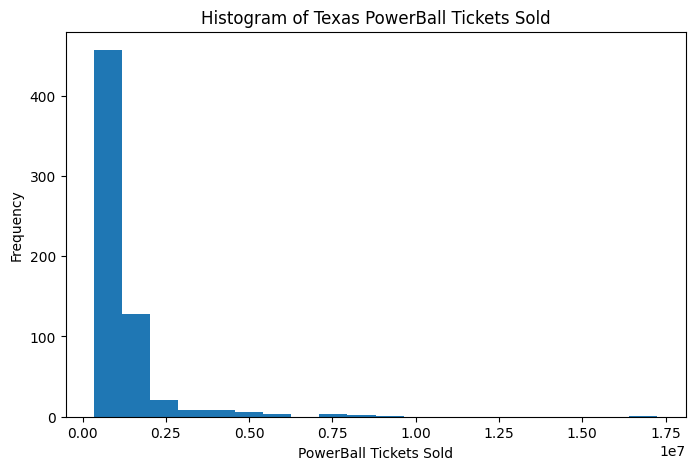

In [57]:
# histogram - show tickets sold distribution 
plt.figure(figsize=(8,5))
plt.hist(df["tickets_sold"],bins=20)
plt.xlabel("PowerBall Tickets Sold")
plt.ylabel("Frequency")
plt.title("Histogram of Texas PowerBall Tickets Sold")
plt.show()

Texas PowerBall ticket sales are heavily right-skewed. Most observations are concentrated below about 2 million tickets, while the distribution has a long right tail with extreme high-sales observations reaching about 17.26 million tickets. This indicates substantial skewness and high-value outliers, suggesting that a log transformation may be appropriate before modeling.

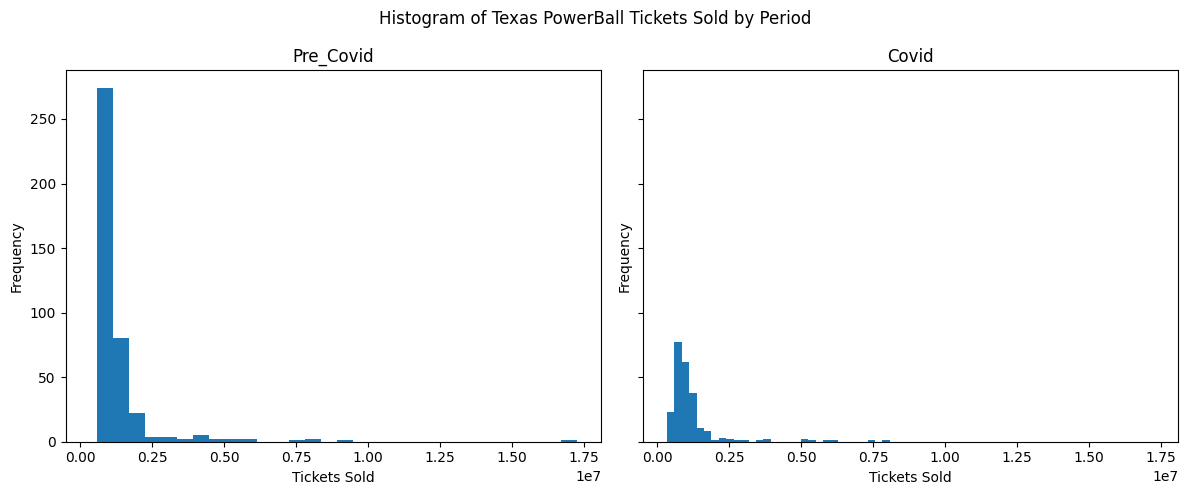

In [58]:
# histogram of tickets sold by periods for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "tickets_sold"], bins=30)
axes[0].set_title("Pre_Covid")
axes[0].set_xlabel("Tickets Sold")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "tickets_sold"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Tickets Sold")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Texas PowerBall Tickets Sold by Period")
plt.tight_layout()
plt.show()

Texas PowerBall ticket sales are right-skewed in both the Pre_Covid and Covid periods. The Pre_Covid distribution has a wider spread and more extreme high-sales observations, while the Covid distribution is more concentrated at lower ticket-sales values. This suggests that ticket sales were generally lower and less variable during Covid, with fewer unusually large sales outcomes.

<br>

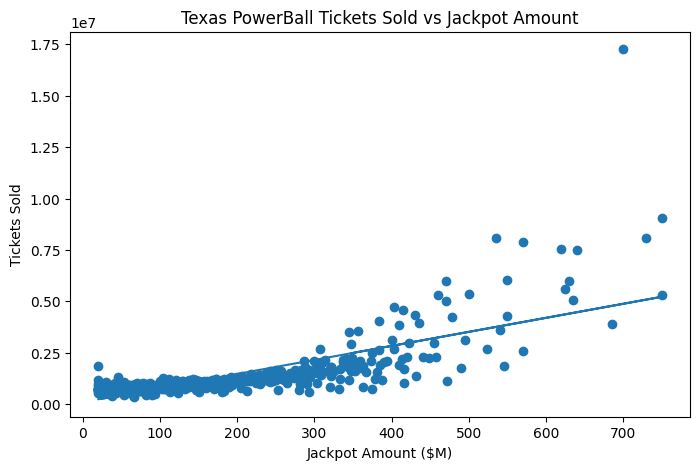

In [59]:
# scatter plot - show how tickets sold changes as the amount of jackpot changes

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot_amount($)"],df["tickets_sold"])

m,b = np.polyfit(df["jackpot_amount($)"], df["tickets_sold"],1)
plt.plot(df["jackpot_amount($)"], m*df["jackpot_amount($)"]+b)

plt.xlabel("Jackpot Amount ($M)")
plt.ylabel("Tickets Sold")
plt.title("Texas PowerBall Tickets Sold vs Jackpot Amount")
plt.show()

Texas PowerBall ticket sales show a clear positive association with jackpot amount. As the jackpot increases, ticket sales generally increase as well, although the spread becomes wider at higher jackpot levels. This suggests that larger jackpots are associated with higher ticket sales, but also with greater variability and several extreme high-sales observations.

<br>

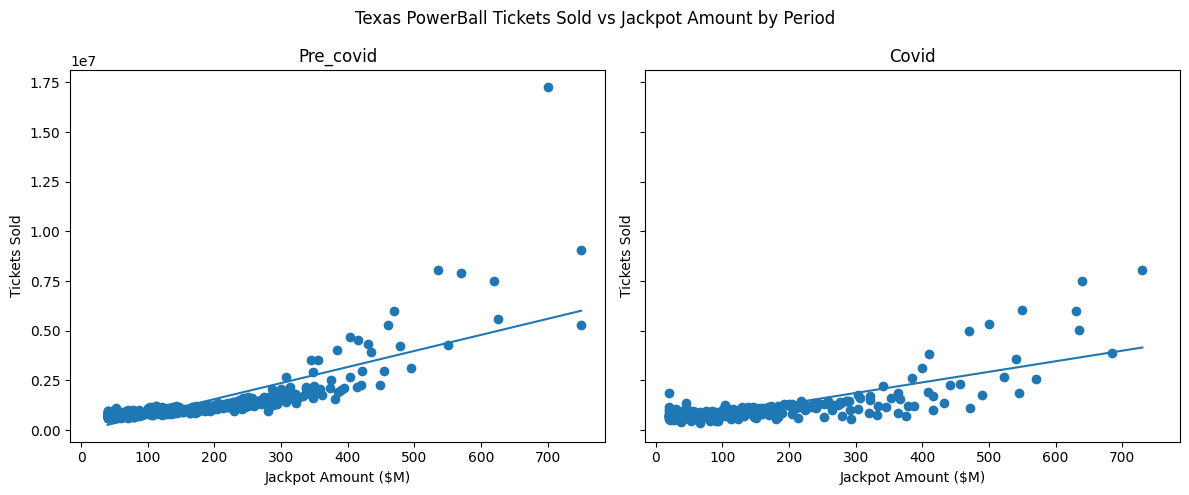

In [60]:
# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot_amount($)"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "tickets_sold"] # locate the covid==0 rows, and take the corresponding tickets sold 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Jackpot Amount ($M)")
axes[0].set_ylabel("Tickets Sold")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot_amount($)"]
y_covid = df.loc[df["covid"] == 1, "tickets_sold"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount ($M)")
axes[1].set_ylabel("Tickets Sold")

plt.suptitle("Texas PowerBall Tickets Sold vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

In both the Pre_Covid and Covid periods, Texas PowerBall ticket sales increase as jackpot amount increases. However, the relationship appears stronger in the Pre_Covid period, where the fitted line is steeper and the highest ticket-sales observations are larger. During Covid, ticket sales still rise with jackpot size, but the response appears weaker and the overall level of ticket sales is lower for comparable jackpot amounts.

<br>

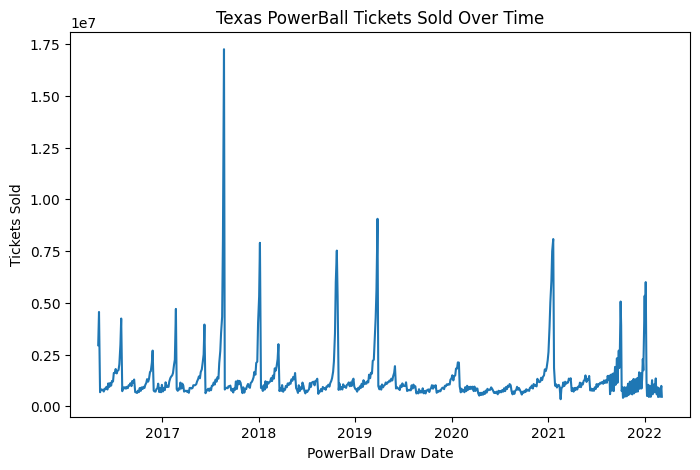

In [61]:
# line plot - show how tickets sold change over time 
plt.figure(figsize=(8,5))
plt.plot(df["draw_date"],df["tickets_sold"])
plt.xlabel("PowerBall Draw Date")
plt.ylabel("Tickets Sold")
plt.title("Texas PowerBall Tickets Sold Over Time")
plt.show()

Texas PowerBall ticket sales fluctuate substantially over time, with recurring sharp spikes corresponding to unusually high-sales draws. Ticket sales appear somewhat lower and less volatile during much of the Covid period, especially around 2020, before rising again later. The series also contains several extreme spikes, including one in 2017 exceeding 17 million tickets sold.

<br>

<Figure size 800x500 with 0 Axes>

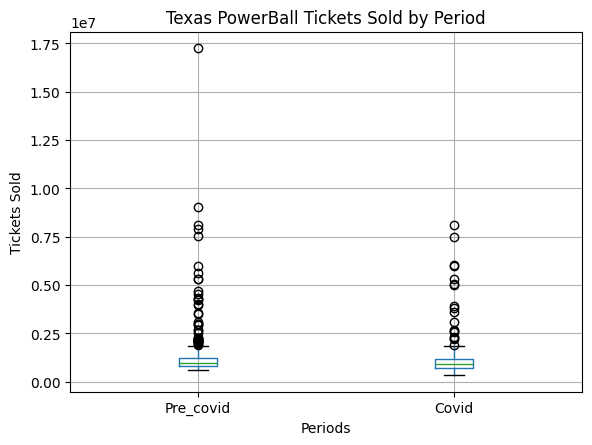

In [62]:
# boxplot 
# define a new variable "covid_label" - using map() -  covid_period =0 as "Pre_covid" and =1 as "Covid"
# pre_covid: May 04,2016 - March 03,2020; covid: March 04,2020 - March 07, 2022 
# May 04, 2016 is the earliest date lottery information could be found online and March 07 is the day this project began.
df["covid_label"] = pd.Categorical(
    df["covid_period"].map({0:"Pre_covid", 1:"Covid"}),
    categories=["Pre_covid", "Covid"],
    ordered=True
) # used pd.Categorical() to treat "covid_label" as categorical and not ordinal; ordered=True ensures Pre_covid is in front of Covid

plt.figure(figsize=(8,5))
df.boxplot(column = "tickets_sold", by="covid_label")

plt.title("Texas PowerBall Tickets Sold by Period")
plt.suptitle("") # to clean the auto title 
plt.xlabel("Periods")
plt.ylabel("Tickets Sold")
plt.show()

The boxplot shows that Texas PowerBall ticket sales had a slightly higher median and a wider spread in the Pre_Covid period than during Covid. Both periods contain many high-sales outliers, but the most extreme observations occurred before Covid, including one above 17 million tickets sold. This suggests that ticket sales were somewhat lower and less variable during Covid, with fewer extremely large sales draws.

<br>

In [63]:
# correlation coefficient tests on tickets sold and jackpot amount 
# Pearson's p and Spearman Rank Order Correlation 
print("Pearson's Correlation:")
print(df[["jackpot_amount($)","tickets_sold"]].corr(method="pearson"))

print("Spearman's Correlation:")
print(df[["jackpot_amount($)","tickets_sold"]].corr(method="spearman"))

Pearson's Correlation:
                   jackpot_amount($)  tickets_sold
jackpot_amount($)           1.000000      0.752589
tickets_sold                0.752589      1.000000
Spearman's Correlation:
                   jackpot_amount($)  tickets_sold
jackpot_amount($)           1.000000      0.819851
tickets_sold                0.819851      1.000000


Both the Pearson and Spearman correlations show a strong positive association between PowerBall tickets sold and jackpot amount, suggesting that the positive relationship is stable, even though the data still show skewness and outliers.

<br>

All graphs and summary statistics indicate that the data is heavily right-skewed and contains several extremely high-value tickets sold outliers. To ensure a robust model, I will analyze these outliers before building the models.

# Outlier Detection for tickets solds
### 3 standard deviation rule 
### Hampel Identifier
### IQR - already done above

In [64]:
# 3 standard deviation rule 
mean_tickets_sold = df["tickets_sold"].mean()
std_tickets_sold = df["tickets_sold"].std()

lower_3std = mean_tickets_sold - 3*std_tickets_sold
upper_3std = mean_tickets_sold + 3*std_tickets_sold

outliers_std = df[(df["tickets_sold"]<lower_3std)|(df["tickets_sold"]>upper_3std)]

print("3 Standard Deviation Rule:")
print("Lower Bound:", lower_3std)
print("Upper Bound:", upper_3std)
print("Number of Outliers", outliers_std.shape[0])

print(outliers_std[["draw_date","jackpot_amount($)","tickets_sold"]])

3 Standard Deviation Rule:
Lower Bound: -2353629.85795156
Upper Bound: 4872688.069406959
Number of Outliers 16
     draw_date  jackpot_amount($)  tickets_sold
135 2017-08-19                535    8080346.80
136 2017-08-23                700   17257718.56
174 2018-01-03                460    5307779.84
175 2018-01-06                570    7898901.60
257 2018-10-20                470    5994780.80
258 2018-10-24                620    7523327.28
259 2018-10-27                750    5314639.12
301 2019-03-23                625    5605258.00
302 2019-03-27                750    9059997.60
489 2021-01-09                470    5014172.00
490 2021-01-13                550    6053218.80
491 2021-01-16                640    7495736.88
492 2021-01-20                730    8082032.88
571 2021-10-02                635    5060884.08
610 2022-01-01                500    5338205.92
612 2022-01-05                630    6000337.20


16 rows of outliers are detected. Since the outlier proportion is about 3% (above the 1% 3std rule threshold), a Hampel comparison is considered.

In [65]:
# hampel identifier 
    ## the hampel use median and MAD is the core part
# MAD:
    ## first calculate the absolute deviation: abs(tickets_sold - median_tickets_sold)
    ## then take the median of those absolute deviations

# Hampel score:
    ## absolute deviation divided by (1.4826 * MAD)
median_tickets_sold = df["tickets_sold"].median()

MAD = np.median(np.abs(df["tickets_sold"]-median_tickets_sold))

hampel_score = np.abs(df["tickets_sold"]-median_tickets_sold)/(1.4826*MAD)

outliers_hampel = df[hampel_score>3]

print("Hample Outliers:")
print("Median:", median_tickets_sold)
print("MAD:", MAD)
print("Number of Outliers:", outliers_hampel.shape[0])

print(outliers_hampel[["draw_date","jackpot_amount($)","tickets_sold"]])

Hample Outliers:
Median: 960490.8
MAD: 208652.40000000002
Number of Outliers: 59
     draw_date  jackpot_amount($)  tickets_sold
0   2016-05-04                348    2949950.24
1   2016-05-07                415    4556516.24
23  2016-07-23                390    2030308.56
24  2016-07-27                422    2970068.24
25  2016-07-30                478    4239494.88
58  2016-11-23                359    2095874.08
59  2016-11-26                403    2689450.88
82  2017-02-15                310    2011340.16
83  2017-02-18                349    2245207.12
84  2017-02-22                403    4704316.48
113 2017-06-03                337    2070506.24
114 2017-06-07                375    2504825.12
115 2017-06-10                435    3948109.60
131 2017-08-05                286    2085566.00
132 2017-08-09                307    2671210.56
133 2017-08-12                356    3544370.08
134 2017-08-16                430    4328397.28
135 2017-08-19                535    8080346.80
136 201

Hampel detected 59 outlier rows, which is substantially higher than the 3 standard deviation rule. Given the right-skewed distribution of the data, this suggests that the 3 standard deviation rule may be influenced by extreme values because it depends on the mean and standard deviation. The IQR method will be considered next.

In [66]:
# IQR
Q1 = df["tickets_sold"].quantile(0.25)
Q3 = df["tickets_sold"].quantile(0.75)
IQR = Q3-Q1

lower_IQR = Q1 - 1.5*IQR
upper_IQR = Q3 + 1.5*IQR

outliers_IQR = df[(df["tickets_sold"]<lower_IQR)|(df["tickets_sold"]>upper_IQR)]

print("Interquartile Range (IQR) Outliers:")
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_IQR)
print("Upper Bound:", upper_IQR)
print("Number of Outliers:", outliers_IQR.shape[0])

print(outliers_IQR[["draw_date","jackpot_amount($)","tickets_sold"]])

Interquartile Range (IQR) Outliers:
Q1: 794124.52
Q3: 1221909.84
IQR: 427785.32000000007
Lower Bound: 152446.53999999992
Upper Bound: 1863587.8200000003
Number of Outliers: 59
     draw_date  jackpot_amount($)  tickets_sold
0   2016-05-04                348    2949950.24
1   2016-05-07                415    4556516.24
23  2016-07-23                390    2030308.56
24  2016-07-27                422    2970068.24
25  2016-07-30                478    4239494.88
58  2016-11-23                359    2095874.08
59  2016-11-26                403    2689450.88
82  2017-02-15                310    2011340.16
83  2017-02-18                349    2245207.12
84  2017-02-22                403    4704316.48
113 2017-06-03                337    2070506.24
114 2017-06-07                375    2504825.12
115 2017-06-10                435    3948109.60
131 2017-08-05                286    2085566.00
132 2017-08-09                307    2671210.56
133 2017-08-12                356    3544370.08
134 2017

IQR detected 59 outliers, which is exactly the same to the Hampel identifier (59). This suggests that for this right skewed variable, the 3 std method is influenced by large outliers. Therefore the more robust methods IQR and Hampel appear to be more appropriate for detecting outliers. 
This means that the data are not well behaved enough to rely on the mean-based rule; therefore, when modeling, a more robust approach is preferred such as using "log tickets sold" instead of the raw dollar valued "log tickets sold as the target variable.

<br>

# Create a Log Transformed Target Variable:
### log_tickets_sold

In [67]:
# use log transformation to reduce the skewness of the data
df["log_tickets_sold"] = np.log(df["tickets_sold"])

In [68]:
print(df["log_tickets_sold"].describe())

count    639.000000
mean      13.875578
std        0.489270
min       12.733127
25%       13.584995
50%       13.775200
75%       14.015925
max       16.663770
Name: log_tickets_sold, dtype: float64


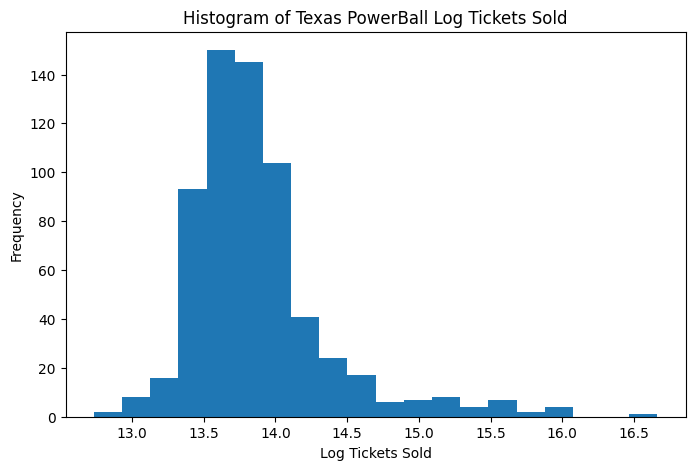

In [69]:
# log_tickets_sold histogram 
plt.figure(figsize=(8,5))
plt.hist(df["log_tickets_sold"],bins=20)
plt.xlabel("Log Tickets Sold")
plt.ylabel("Frequency")
plt.title("Histogram of Texas PowerBall Log Tickets Sold")
plt.show()

After the log transformation, the distribution of Texas PowerBall tickets sold becomes more symmetric and closer to a normal distribution, although some right skew remains.

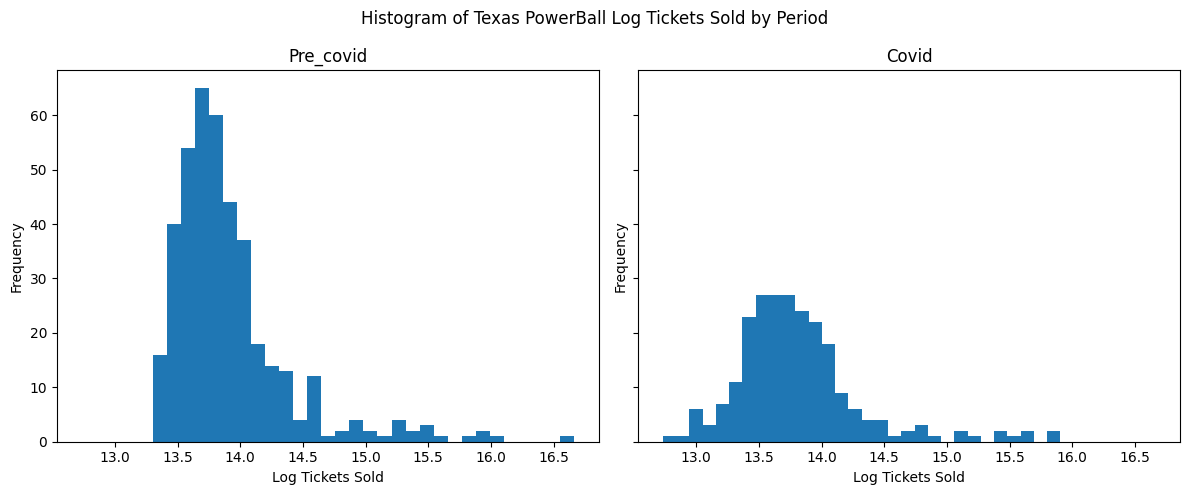

In [70]:
# histogram of log tickets sold by periods for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
axes[0].hist(df.loc[df["covid"] == 0, "log_tickets_sold"], bins=30)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Log Tickets Sold")
axes[0].set_ylabel("Frequency")

# Covid
axes[1].hist(df.loc[df["covid"] == 1, "log_tickets_sold"], bins=30)
axes[1].set_title("Covid")
axes[1].set_xlabel("Log Tickets Sold")
axes[1].set_ylabel("Frequency")

plt.suptitle("Histogram of Texas PowerBall Log Tickets Sold by Period")
plt.tight_layout()
plt.show()

After the log transformation, Texas PowerBall tickets sold in both the Pre_Covid and Covid periods appear less right-skewed and closer to a normal distribution. The Covid distribution is shifted slightly left and appears somewhat more concentrated, while the Pre_Covid period still shows a wider spread and a few larger upper-tail observations. This suggests that log transformation reduces the influence of extreme high-sales draws and makes the period comparison clearer.

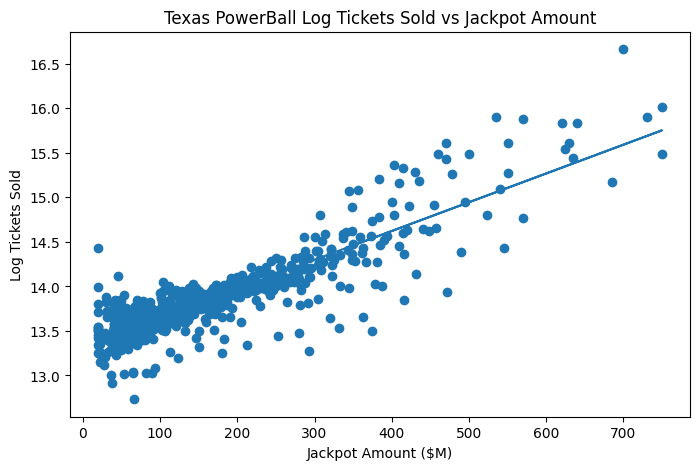

In [71]:
# log scatter plot - show how log tickets sold changes as the amount of jackpot changes

plt.figure(figsize=(8,5))
plt.scatter(df["jackpot_amount($)"],df["log_tickets_sold"])

m,b = np.polyfit(df["jackpot_amount($)"], df["log_tickets_sold"],1)
plt.plot(df["jackpot_amount($)"], m*df["jackpot_amount($)"]+b)

plt.xlabel("Jackpot Amount ($M)")
plt.ylabel("Log Tickets Sold")
plt.title("Texas PowerBall Log Tickets Sold vs Jackpot Amount")
plt.show()

The scatter plot shows a clear positive association between Texas PowerBall jackpot amount and log ticket sales. As the jackpot increases, log ticket sales generally increase as well, indicating that larger jackpots are associated with higher ticket sales. The relationship appears more linear on the log scale, although some variability remains at higher jackpot amounts.

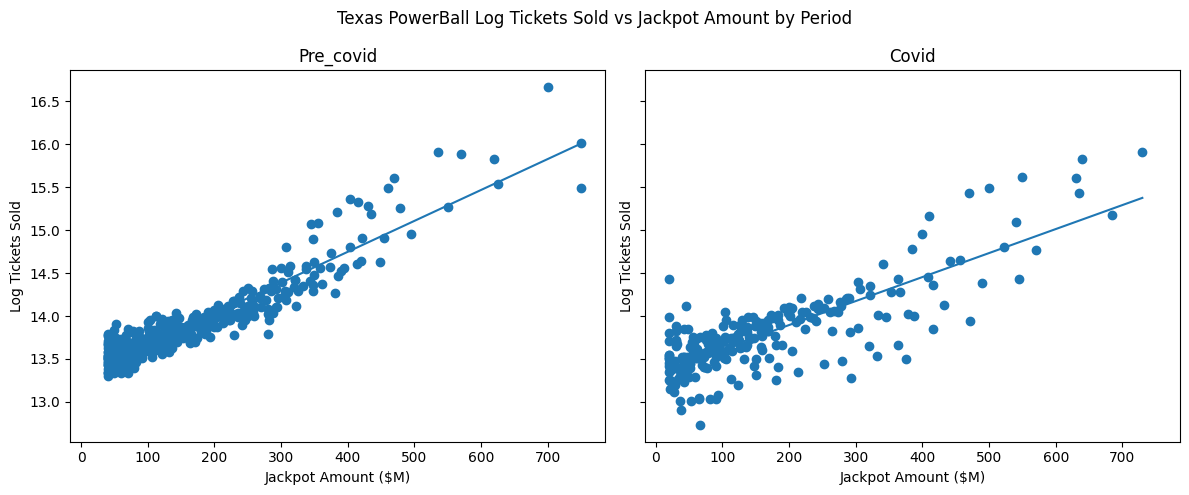

In [72]:
# compare scatter plots of log tickets sold between periods

# set the same scale for both scatter plots and regression lines 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Pre-Covid
x_pre = df.loc[df["covid"] == 0, "jackpot_amount($)"] # locate the covid==0 rows, and take the corresponding jackpot 
y_pre = df.loc[df["covid"] == 0, "log_tickets_sold"] # locate the covid==0 rows, and take the corresponding tickets sold 

axes[0].scatter(x_pre, y_pre)
slope_pre, intercept_pre = np.polyfit(x_pre, y_pre, 1)
x_pre_sorted = np.sort(x_pre)
axes[0].plot(x_pre_sorted, slope_pre * x_pre_sorted + intercept_pre)
axes[0].set_title("Pre_covid")
axes[0].set_xlabel("Jackpot Amount ($M)")
axes[0].set_ylabel("Log Tickets Sold")

# Covid
x_covid = df.loc[df["covid"] == 1, "jackpot_amount($)"]
y_covid = df.loc[df["covid"] == 1, "log_tickets_sold"]

axes[1].scatter(x_covid, y_covid)
slope_covid, intercept_covid = np.polyfit(x_covid, y_covid, 1)
x_covid_sorted = np.sort(x_covid)
axes[1].plot(x_covid_sorted, slope_covid * x_covid_sorted + intercept_covid)
axes[1].set_title("Covid")
axes[1].set_xlabel("Jackpot Amount ($M)")
axes[1].set_ylabel("Log Tickets Sold")

plt.suptitle("Texas PowerBall Log Tickets Sold vs Jackpot Amount by Period")
plt.tight_layout() # adjust spacing automatically (e.g., prevents title overlapping..)
plt.show()

In both the Pre_Covid and Covid periods, Texas PowerBall shows a positive association between jackpot amount and log ticket sales. The relationship appears somewhat stronger and more consistent in the Pre_Covid period, while the Covid period shows greater dispersion around the trend line. Overall, larger jackpots are associated with higher log ticket sales in both periods, but the relationship appears less stable during Covid.

<br>

# Preparation for Building Regression Models
### Check correlation and create new variables

In [73]:
# create "lag_jackpot($)" - each row uses the previous drawing's jackpot amount
# sort by draw_date before creating lag variables
df = df.sort_values("draw_date").reset_index(drop=True)

df["lag_jackpot($)"] = df["jackpot_amount($)"].shift(1)

In [74]:
# create interaction terms: "lag_jackpot_covid", "unemployment_rate_covid", and "lag_jackpot_unemployment_rate"
df["lag_jackpot($)_covid"] = df["lag_jackpot($)"]*df["covid"]
df["unemployment_rate_covid"] = df["unemployment_rate"]*df["covid"]
df["lag_jackpot($)_unemployment_rate"] = df["lag_jackpot($)"]*df["unemployment_rate"]

In [75]:
# create year dummies 
df["year"] = np.nan

df.loc[df["year2016"] == 1, "year"] = 2016
df.loc[df["year2017"] == 1, "year"] = 2017
df.loc[df["year2018"] == 1, "year"] = 2018
df.loc[df["year2019"] == 1, "year"] = 2019
df.loc[df["year2020"] == 1, "year"] = 2020
df.loc[df["year2021"] == 1, "year"] = 2021
df.loc[df["year2022"] == 1, "year"] = 2022

<br>

# Build 3 Regression Models

In [76]:
# check variables again 
print(df.columns)

Index(['draw_date', 'winners', 'jackpot_amount($)', 'covid', 'covid_cases',
       'monday', 'wednesday', 'unemployment_rate_adjusted',
       'unemployment_rate', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul',
       'aug', 'sept', 'oct', 'nov', 'dec', 'year2016', 'year2017', 'year2018',
       'year2019', 'year2020', 'year2021', 'year2022', 'tickets_sold',
       'covid_period', 'covid_label', 'log_tickets_sold', 'lag_jackpot($)',
       'lag_jackpot($)_covid', 'unemployment_rate_covid',
       'lag_jackpot($)_unemployment_rate', 'year'],
      dtype='object')


In [77]:
# Model 1
# since lag jackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_1 = ["log_tickets_sold", "covid", "lag_jackpot($)", "unemployment_rate", "monday", "wednesday"]
df1 = df[model_vars_1].dropna()

# choose predictors and target variable
X1 = df1[["covid","lag_jackpot($)","unemployment_rate","monday","wednesday"]]
X1 = sm.add_constant(X1)
y = df1["log_tickets_sold"]

# fit the model
model1 = sm.OLS(y,X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:       log_tickets_sold   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     177.7
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          6.60e-118
Time:                        18:04:40   Log-Likelihood:                -167.02
No. Observations:                 638   AIC:                             346.0
Df Residuals:                     632   BIC:                             372.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                13.5977      0.04

In [78]:
# Model 2
# since lag jackpot was created using "shift1", the first row may be empty and it needs to be dropped 
model_vars_2 = ["log_tickets_sold", "covid", "lag_jackpot($)", "lag_jackpot($)_covid","unemployment_rate", "unemployment_rate_covid","monday", "wednesday"]
df2 = df[model_vars_2].dropna()

# choose predictors and target variable
X2 = df2[["covid","lag_jackpot($)","lag_jackpot($)_covid","unemployment_rate","unemployment_rate_covid","monday","wednesday"]]
X2 = sm.add_constant(X2)
y = df2["log_tickets_sold"]

# fit the model
model2 = sm.OLS(y,X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:       log_tickets_sold   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     127.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          2.35e-116
Time:                        18:04:40   Log-Likelihood:                -165.38
No. Observations:                 638   AIC:                             346.8
Df Residuals:                     630   BIC:                             382.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [79]:
# Model 3
# since lag jackpot was created using "shift1", the first row may be empty and it needs to be dropped 

model_vars_3 = ["log_tickets_sold", "covid", "lag_jackpot($)", "lag_jackpot($)_covid","unemployment_rate", "unemployment_rate_covid","lag_jackpot($)_unemployment_rate","monday", "wednesday"]
df3 = df[model_vars_3].dropna()

# choose predictors and target variable
X3 = df3[["covid","lag_jackpot($)","lag_jackpot($)_covid","unemployment_rate","unemployment_rate_covid","lag_jackpot($)_unemployment_rate","monday","wednesday"]]
X3 = sm.add_constant(X3)
y = df3["log_tickets_sold"]

# fit the model
model3 = sm.OLS(y,X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_tickets_sold   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     113.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          9.28e-117
Time:                        18:04:40   Log-Likelihood:                -161.92
No. Observations:                 638   AIC:                             341.8
Df Residuals:                     629   BIC:                             382.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

<br>

# Compare the models 
### AIC, BIC, Adjusted-R^2

In [80]:
model_comparison_table = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "n_obs": [model1.nobs, model2.nobs, model3.nobs],
    "R_squared": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R_squared": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

model_comparison_table

,Model,n_obs,R_squared,Adj_R_squared,AIC,BIC
0,Model 1,638.0,0.584283,0.580995,346.041580,372.791610
1,Model 2,638.0,0.586417,0.581822,346.758201,382.424908
2,Model 3,638.0,0.590880,0.585677,341.836705,381.961750


On the log ticket-sales scale, Model 3 was selected as the final model for Texas PowerBall. It has the highest adjusted R-squared (0.5857) and the lowest AIC (341.84) and BIC (381.96), indicating the best overall fit among the three candidate models.

<br>

# Post Model Inference

In [81]:
def linear_combination_test(results, weights_dict, label="Quantity"):
    parameter_names = results.params.index
    weight_vector = pd.Series(0.0, index=parameter_names)

    for name, weight in weights_dict.items():
        weight_vector[name] = weight

    test_result = results.t_test(weight_vector.values)

    estimate = test_result.effect.item()
    standard_error = test_result.sd.item()
    t_value = test_result.tvalue.item()
    p_value = test_result.pvalue.item()
    ci_lower, ci_upper = test_result.conf_int()[0]

    output = pd.DataFrame({
        "Quantity": [label],
        "Estimate": [estimate],
        "Std_Error": [standard_error],
        "t_value": [t_value],
        "p_value": [p_value],
        "CI_Lower_95": [ci_lower],
        "CI_Upper_95": [ci_upper]
    })

    return output


# sample means used in Model 3 interpretation
mean_lag_jackpot_3 = df3["lag_jackpot($)"].mean()
mean_unempr_3 = df3["unemployment_rate"].mean()
mean_interaction_3 = mean_lag_jackpot_3 * mean_unempr_3
mean_monday_3 = df3["monday"].mean()
mean_wednesday_3 = df3["wednesday"].mean()


# 1) predicted mean log ticket sales before Covid
predicted_mean_before_weights = {
    "const": 1,
    "lag_jackpot($)": mean_lag_jackpot_3,
    "unemployment_rate": mean_unempr_3,
    "lag_jackpot($)_unemployment_rate": mean_interaction_3,
    "monday": mean_monday_3,
    "wednesday": mean_wednesday_3
}

predicted_mean_before_result = linear_combination_test(
    model3,
    predicted_mean_before_weights,
    label="Predicted Mean Log Ticket Sales Before Covid"
)


# 2) predicted mean log ticket sales during Covid
predicted_mean_during_weights = {
    "const": 1,
    "covid": 1,
    "lag_jackpot($)": mean_lag_jackpot_3,
    "lag_jackpot($)_covid": mean_lag_jackpot_3,
    "unemployment_rate": mean_unempr_3,
    "unemployment_rate_covid": mean_unempr_3,
    "lag_jackpot($)_unemployment_rate": mean_interaction_3,
    "monday": mean_monday_3,
    "wednesday": mean_wednesday_3
}

predicted_mean_during_result = linear_combination_test(
    model3,
    predicted_mean_during_weights,
    label="Predicted Mean Log Ticket Sales During Covid"
)


# 3) difference in predicted mean log ticket sales (during - before)
difference_in_predicted_mean_weights = {
    "covid": 1,
    "lag_jackpot($)_covid": mean_lag_jackpot_3,
    "unemployment_rate_covid": mean_unempr_3
}

difference_in_predicted_mean_result = linear_combination_test(
    model3,
    difference_in_predicted_mean_weights,
    label="Difference in Predicted Mean Log Ticket Sales (during - before)"
)


# 4) marginal effect of lagged jackpot before Covid
marginal_effect_lagjackpot_before_weights = {
    "lag_jackpot($)": 1,
    "lag_jackpot($)_unemployment_rate": mean_unempr_3
}

marginal_effect_lagjackpot_before_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_before_weights,
    label="Marginal Effect of Lagged Jackpot Before Covid"
)


# 5) marginal effect of lagged jackpot during Covid
marginal_effect_lagjackpot_during_weights = {
    "lag_jackpot($)": 1,
    "lag_jackpot($)_covid": 1,
    "lag_jackpot($)_unemployment_rate": mean_unempr_3
}

marginal_effect_lagjackpot_during_result = linear_combination_test(
    model3,
    marginal_effect_lagjackpot_during_weights,
    label="Marginal Effect of Lagged Jackpot During Covid"
)


# 6) difference in marginal effect of lagged jackpot
difference_in_marginal_effect_lagjackpot_weights = {
    "lag_jackpot($)_covid": 1
}

difference_in_marginal_effect_lagjackpot_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_lagjackpot_weights,
    label="Difference in Marginal Effect of Lagged Jackpot"
)


# 7) marginal effect of unemployment rate before Covid
marginal_effect_unempr_before_weights = {
    "unemployment_rate": 1,
    "lag_jackpot($)_unemployment_rate": mean_lag_jackpot_3
}

marginal_effect_unempr_before_result = linear_combination_test(
    model3,
    marginal_effect_unempr_before_weights,
    label="Marginal Effect of Unemployment Rate Before Covid"
)


# 8) marginal effect of unemployment rate during Covid
marginal_effect_unempr_during_weights = {
    "unemployment_rate": 1,
    "unemployment_rate_covid": 1,
    "lag_jackpot($)_unemployment_rate": mean_lag_jackpot_3
}

marginal_effect_unempr_during_result = linear_combination_test(
    model3,
    marginal_effect_unempr_during_weights,
    label="Marginal Effect of Unemployment Rate During Covid"
)


# 9) difference in marginal effect of unemployment rate
difference_in_marginal_effect_unempr_weights = {
    "unemployment_rate_covid": 1
}

difference_in_marginal_effect_unempr_result = linear_combination_test(
    model3,
    difference_in_marginal_effect_unempr_weights,
    label="Difference in Marginal Effect of Unemployment Rate"
)


# combine all post-estimation results
model3_post_estimation_table = pd.concat([
    predicted_mean_before_result,
    predicted_mean_during_result,
    difference_in_predicted_mean_result,
    marginal_effect_lagjackpot_before_result,
    marginal_effect_lagjackpot_during_result,
    difference_in_marginal_effect_lagjackpot_result,
    marginal_effect_unempr_before_result,
    marginal_effect_unempr_during_result,
    difference_in_marginal_effect_unempr_result
], ignore_index=True)

model3_post_estimation_table

,Quantity,Estimate,Std_Error,t_value,p_value,CI_Lower_95,CI_Upper_95
0,Predicted Mean Log Ticket Sales Before Covid,13.918158,0.030555,455.509152,0.000000e+00,13.858155,13.978160
1,Predicted Mean Log Ticket Sales During Covid,13.879226,0.027457,505.497732,0.000000e+00,13.825308,13.933143
2,Difference in Predicted Mean Log Ticket Sales ...,-0.038932,0.041772,-0.932024,3.516818e-01,-0.120961,0.043096
3,Marginal Effect of Lagged Jackpot Before Covid,0.002909,0.000156,18.699762,2.206310e-62,0.002604,0.003215
4,Marginal Effect of Lagged Jackpot During Covid,0.002439,0.000162,15.045655,6.340580e-44,0.002120,0.002757
5,Difference in Marginal Effect of Lagged Jackpot,-0.000471,0.000251,-1.876509,6.104824e-02,-0.000963,0.000022
6,Marginal Effect of Unemployment Rate Before Covid,0.032579,0.028351,1.149121,2.509429e-01,-0.023095,0.088252
7,Marginal Effect of Unemployment Rate During Covid,-0.003227,0.012375,-0.260788,7.943412e-01,-0.027530,0.021075
8,Difference in Marginal Effect of Unemployment ...,-0.035806,0.031024,-1.154134,2.488835e-01,-0.096729,0.025117


Conclusion: Holding the other variables at their sample means, Texas PowerBall predicted log ticket sales were slightly lower during Covid, but the difference was not statistically significant. The lagged jackpot effect remained positive in both periods and was somewhat smaller during Covid, though the difference was only marginal. The unemployment-rate effect was not statistically significant in either period.